<a href="https://colab.research.google.com/github/ZiyadRhazi/ZiyadRhazi/blob/main/proba_ziyad_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
import sys

def install_packages():
    """Install all required packages silently (pymc, numpy, matplotlib, etc.)"""
    packages = ['pymc', 'numpy', 'matplotlib', 'arviz', 'scipy', 'pandas']
    for package in packages:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    print("✅ All packages installed successfully!")


In [2]:
import numpy as np
import matplotlib.pyplot as plt # Added for visualization (essential for Colab scripts)
import pandas as pd
from scipy.stats import norm, chi2
import warnings
warnings.filterwarnings('ignore')

try:
    import pymc as pm
    import arviz as az
    print(f"✅ PyMC version: {pm.__version__}")
    print(f"✅ ArviZ version: {az.__version__}")
except ImportError:
    print("⚠️ PyMC not found. Please run the installation function above.")

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("\n✅ All libraries imported successfully!")

✅ PyMC version: 5.26.1
✅ ArviZ version: 0.22.0

✅ All libraries imported successfully!


In [3]:

# Time configuration
T = 100              # Number of timesteps
dt = 0.1             # Time step (seconds)
time = np.arange(T) * dt

# Initial conditions
initial_position = 0.0      # meters
initial_velocity = 10.0     # m/s
acceleration = 0.5          # m/s²

# State transition matrix (constant acceleration model)
# Derived from: x(t+Δt) = x(t) + v(t)⋅Δt + ½a⋅Δt²
#               v(t+Δt) = v(t) + a⋅Δt
Phi = np.array([
    [1, dt],      # position_new = position + velocity*dt
    [0, 1]        # velocity_new = velocity (+ process noise)
])

# Control input matrix (acceleration effect)
Gamma = np.array([
    [0.5 * dt**2],     # position effect: ½at²
    [dt]               # velocity effect: at
])

# Measurement matrix (we observe position from sensors)
H = np.array([[1, 0]])  # Extract position from state vector
H_velocity = np.array([[0, 1]])  # Extract velocity from state vector

# Process noise (model uncertainty)
q_position = 0.1   # Position process noise
q_velocity = 0.05  # Velocity process noise
Q = np.array([
    [q_position, 0],
    [0, q_velocity]
])

# Sensor noise characteristics (based on real specifications)
sensor_params = {
    'LiDAR': {'sigma': 0.5, 'color': 'green', 'marker': 'o', 'alpha': 0.3},
    'Radar': {'sigma': 2.0, 'color': 'blue', 'marker': 's', 'alpha': 0.3},
    'Camera': {'sigma': 4.0, 'color': 'red', 'marker': '^', 'alpha': 0.3}
}

sigma_velocity = 0.1  # Radar Doppler velocity measurement noise (m/s)

print("="*80)
print(" SYSTEM CONFIGURATION SUMMARY")
print("="*80)
print(f"\nDuration: {T*dt:.1f} seconds")
print(f"Initial Velocity: {initial_velocity:.1f} m/s | Acceleration: {acceleration:.2f} m/s²")
print(f"Sensor Noise (Position σ): LiDAR={sensor_params['LiDAR']['sigma']:.2f}, Radar={sensor_params['Radar']['sigma']:.2f}, Camera={sensor_params['Camera']['sigma']:.2f}")
print("="*80)


 SYSTEM CONFIGURATION SUMMARY

Duration: 10.0 seconds
Initial Velocity: 10.0 m/s | Acceleration: 0.50 m/s²
Sensor Noise (Position σ): LiDAR=0.50, Radar=2.00, Camera=4.00


In [4]:
print("\nGenerating ground truth trajectory and noisy sensor measurements...")

# Initialize state arrays
true_state = np.zeros((T, 2))  # [position, velocity]
true_state[0] = [initial_position, initial_velocity]

# Propagate dynamics with process noise
for k in range(1, T):
    # Add process noise (model uncertainty)
    process_noise = np.random.multivariate_normal([0, 0], Q)

    # State propagation: x_k = Φ⋅x_{k-1} + Γ⋅u + w_k
    true_state[k] = Phi @ true_state[k-1] + Gamma.flatten() * acceleration + process_noise

# Initialize measurement arrays
measurements = {sensor: np.zeros(T) for sensor in sensor_params.keys()}
measurements['velocity'] = np.zeros(T)

# Generate noisy measurements from each sensor
for sensor, params in sensor_params.items():
    noise = np.random.normal(0, params['sigma'], T)
    measurements[sensor] = true_state[:, 0] + noise

# Radar velocity measurements (Doppler)
velocity_noise = np.random.normal(0, sigma_velocity, T)
measurements['velocity'] = true_state[:, 1] + velocity_noise

print(f"✅ Data generated: {T} timesteps of ground truth and multi-sensor measurements.")


Generating ground truth trajectory and noisy sensor measurements...
✅ Data generated: 100 timesteps of ground truth and multi-sensor measurements.


In [5]:
def kalman_filter(measurements, sensor_sigmas, velocity_measurements=None, verbose=True):
    """
    Implement classical Kalman Filter with multi-sensor fusion.
    This is the OPTIMAL Bayesian estimator for linear-Gaussian systems.
    """

    n_steps = len(measurements[list(measurements.keys())[0]])

    # Initialize estimates
    x_est = np.zeros((n_steps, 2))
    P_est = np.zeros((n_steps, 2, 2))

    # Initial state estimate (rough guess)
    x_est[0] = [0, 10]  # position ≈ 0, velocity ≈ 10 m/s
    P_est[0] = np.eye(2) * 10  # High initial uncertainty

    # Storage for diagnostic information
    innovations = []
    kalman_gains = []

    if verbose:
        print("\n" + "="*80)
        print(" KALMAN FILTER EXECUTION")
        print("="*80)

    # Main Kalman Filter loop
    for k in range(1, n_steps):
        # --------------------------------------------------------------------
        # PREDICTION STEP (Prior)
        # --------------------------------------------------------------------
        x_pred = Phi @ x_est[k-1] + Gamma.flatten() * acceleration
        P_pred = Phi @ P_est[k-1] @ Phi.T + Q

        # --------------------------------------------------------------------
        # UPDATE STEP (Posterior) - Multi-sensor fusion
        # --------------------------------------------------------------------
        x_update = x_pred.copy()
        P_update = P_pred.copy()

        # Sequential update with each position sensor
        for sensor, sigma in sensor_sigmas.items():
            R = np.array([[sigma**2]])  # Measurement noise covariance (R)

            # Innovation covariance (S)
            S = H @ P_update @ H.T + R

            # Kalman Gain (K)
            K = P_update @ H.T @ np.linalg.inv(S)

            # Innovation (measurement residual: y)
            y = measurements[sensor][k] - H @ x_update

            # State update
            x_update = x_update + (K @ y).flatten()

            # Covariance update (P)
            P_update = (np.eye(2) - K @ H) @ P_update

            innovations.append(y[0])
            kalman_gains.append(K[0, 0])

        # Update with velocity measurement if available
        if velocity_measurements is not None:
            R_vel = np.array([[sigma_velocity**2]])
            S_vel = H_velocity @ P_update @ H_velocity.T + R_vel
            K_vel = P_update @ H_velocity.T @ np.linalg.inv(S_vel)

            y_vel = velocity_measurements[k] - H_velocity @ x_update
            x_update = x_update + (K_vel @ y_vel).flatten()
            P_update = (np.eye(2) - K_vel @ H_velocity) @ P_update

            innovations.append(y_vel[0])

        # Store estimates
        x_est[k] = x_update
        P_est[k] = P_update

    if verbose:
        print(f"✅ Kalman Filter completed successfully")
        print(f"  Final state: [{x_est[-1,0]:.2f}, {x_est[-1,1]:.2f}]")
        print(f"  Final uncertainty: σ_pos={np.sqrt(P_est[-1,0,0]):.3f}m, σ_vel={np.sqrt(P_est[-1,1,1]):.3f}m/s")
        print("="*80)

    return x_est, P_est, innovations, kalman_gains


# RUN KALMAN FILTER
sensor_sigmas = {s: p['sigma'] for s, p in sensor_params.items()}

kf_state, kf_covariance, innovations, gains = kalman_filter(
    measurements,
    sensor_sigmas,
    measurements['velocity'],
    verbose=True
)

# Calculate performance metrics
rmse_position = np.sqrt(np.mean((kf_state[:, 0] - true_state[:, 0])**2))
rmse_velocity = np.sqrt(np.mean((kf_state[:, 1] - true_state[:, 1])**2))
mae_position = np.mean(np.abs(kf_state[:, 0] - true_state[:, 0]))
mae_velocity = np.mean(np.abs(kf_state[:, 1] - true_state[:, 1]))

print(f"\nPerformance Metrics (Kalman Filter):")
print(f"  Position RMSE: {rmse_position:.4f} m")
print(f"  Velocity RMSE: {rmse_velocity:.4f} m/s")



 KALMAN FILTER EXECUTION
✅ Kalman Filter completed successfully
  Final state: [116.44, 15.87]
  Final uncertainty: σ_pos=0.332m, σ_vel=0.092m/s

Performance Metrics (Kalman Filter):
  Position RMSE: 0.3012 m
  Velocity RMSE: 0.0889 m/s


In [7]:
# ============================================================================
# BUILD BAYESIAN MODEL
# ============================================================================

with pm.Model() as bayesian_model:

    # Priors - Weakly informative
    position = pm.Normal('position', mu=50, sigma=50, shape=subset_size)
    velocity = pm.Normal('velocity', mu=12, sigma=10, shape=subset_size)

    # INNOVATION: Temporal smoothness constraints (Process Model)
    # Corrected: Use pm.Potential to define the likelihood of a transition
    # between random variables (position[i-1] -> position[i]), as 'observed'
    # only accepts fixed data.
    for i in range(1, subset_size):
        dt_sub = subset_time[i] - subset_time[i-1]

        # Position evolution (Process Noise equivalent)
        mu_pos = position[i-1] + velocity[i-1] * dt_sub
        sigma_pos = 3.0
        pm.Potential(f'smooth_pos_{i}', pm.logp(pm.Normal.dist(mu=mu_pos, sigma=sigma_pos), position[i]))

        # Velocity evolution (Process Noise equivalent)
        mu_vel = velocity[i-1]
        sigma_vel = 1.5
        pm.Potential(f'smooth_vel_{i}', pm.logp(pm.Normal.dist(mu=mu_vel, sigma=sigma_vel), velocity[i]))

    # Likelihoods - Connect to sensor observations (Measurement Model)
    # This is the Bayes' update step (P(Z|X))
    for sensor, params in sensor_params.items():
        pm.Normal(f'obs_{sensor}',
                 mu=position,
                 sigma=params['sigma'],
                 observed=measurements[sensor][subset_idx])

    # Radar Doppler velocity likelihood
    pm.Normal('obs_velocity',
             mu=velocity,
             sigma=sigma_velocity,
             observed=measurements['velocity'][subset_idx])

print("✅ Bayesian model constructed")

# ... rest of the code remains the same ...

✅ Bayesian model constructed


In [9]:
# ============================================================================
# RUN MCMC SAMPLING
# ============================================================================

print("\nRunning MCMC sampling... (This may take a minute) ☕\n")

with bayesian_model:
    # Use NUTS (No-U-Turn Sampler), a gradient-based MCMC algorithm
    trace = pm.sample(
        2000,                    # Number of samples (draws)
        tune=1000,              # Tuning/warmup samples
        cores=1,                # CPU cores (use 1 for Colab stability)
        return_inferencedata=True,
        progressbar=True,
        random_seed=42
    )

print("\n✅ MCMC sampling complete!")

# ============================================================================
# EXTRACT POSTERIOR STATISTICS
# ============================================================================

# Calculate the mean of the posterior distributions for state estimation
posterior_position = trace.posterior['position'].mean(dim=['chain', 'draw']).values
posterior_velocity = trace.posterior['velocity'].mean(dim=['chain', 'draw']).values

# Calculate the standard deviation (uncertainty) of the posterior distributions
posterior_position_std = trace.posterior['position'].std(dim=['chain', 'draw']).values
posterior_velocity_std = trace.posterior['velocity'].std(dim=['chain', 'draw']).values


Running MCMC sampling... (This may take a minute) ☕



Output()


✅ MCMC sampling complete!


In [10]:
# Calculate PyMC performance metrics for the subset used
rmse_position_bayes = np.sqrt(np.mean((posterior_position - true_state[subset_idx, 0])**2))
rmse_velocity_bayes = np.sqrt(np.mean((posterior_velocity - true_state[subset_idx, 1])**2))

print(f"\nPerformance Metrics (Bayesian Inference, Subset T={subset_size}):")
print(f"  Position RMSE: {rmse_position_bayes:.4f} m")
print(f"  Velocity RMSE: {rmse_velocity_bayes:.4f} m/s")


Performance Metrics (Bayesian Inference, Subset T=30):
  Position RMSE: 0.4798 m
  Velocity RMSE: 0.0924 m/s


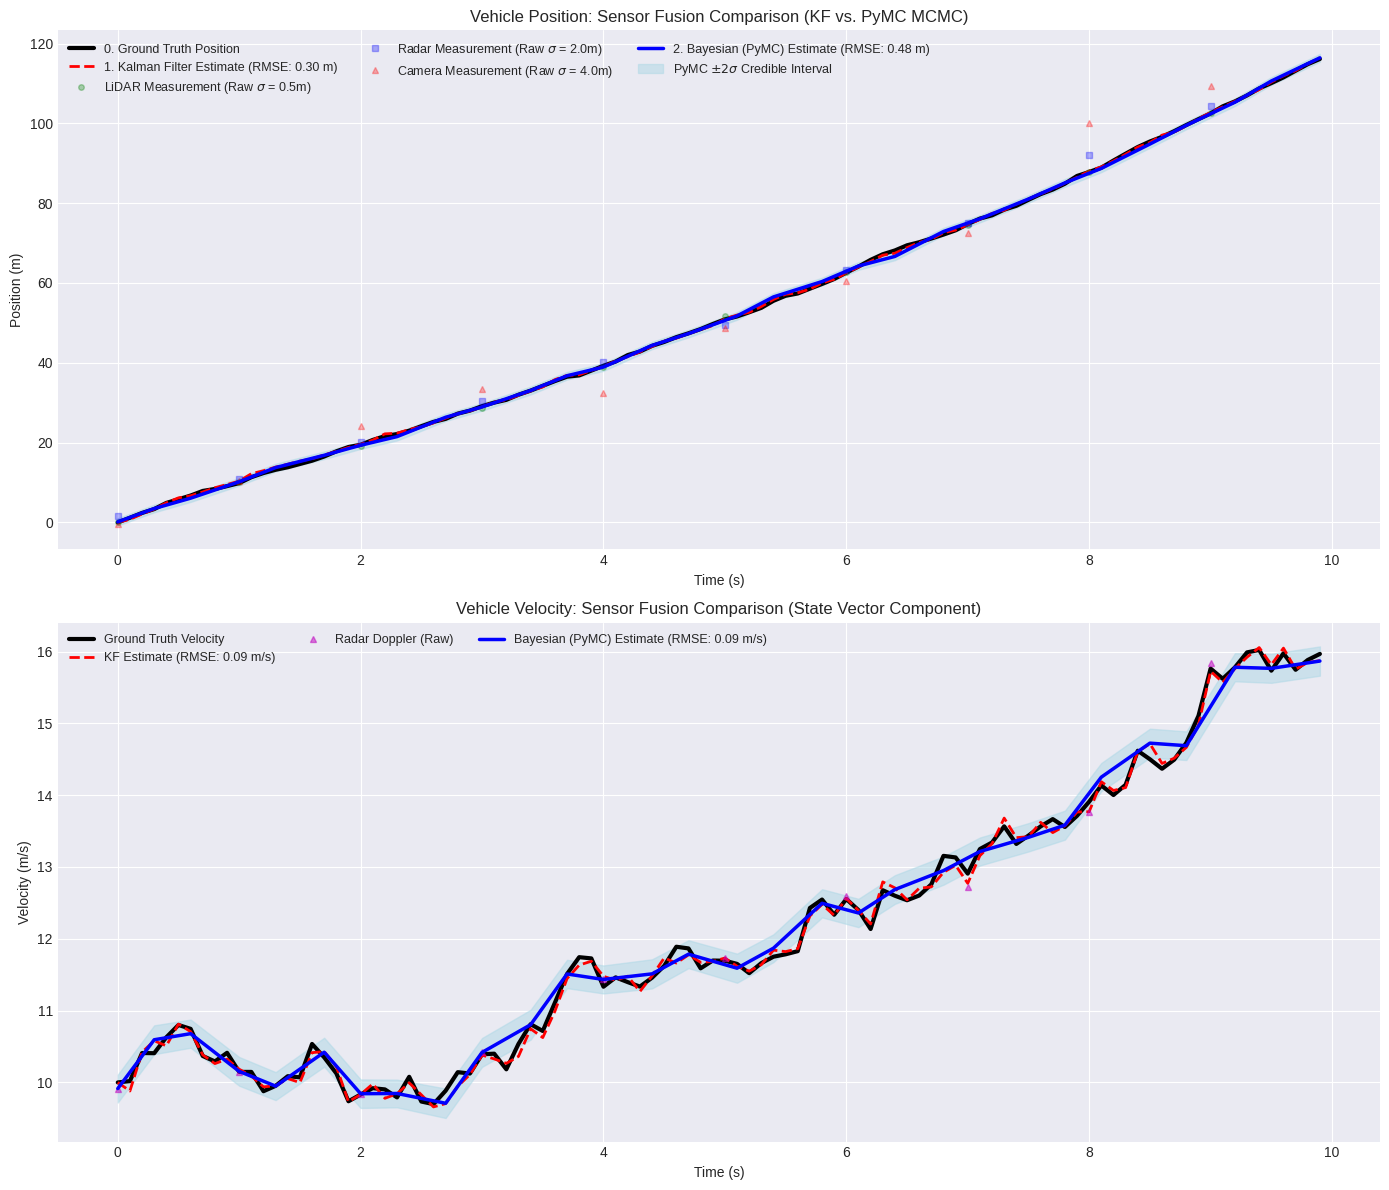

In [12]:
plt.figure(figsize=(14, 12))

# --- Position Plot ---
plt.subplot(2, 1, 1)
plt.plot(time, true_state[:, 0], 'k-', linewidth=3, label='0. Ground Truth Position')
plt.plot(time, kf_state[:, 0], 'r--', linewidth=2, label=f'1. Kalman Filter Estimate (RMSE: {rmse_position:.2f} m)')

# Plot raw sensor data (subset for clarity)
for sensor, params in sensor_params.items():
    # FIX: Pass color and marker separately using keywords 'c' and 'marker'
    plt.plot(time[::10], measurements[sensor][::10],
             c=params['color'],
             marker=params['marker'],
             linestyle='', # Ensure no line connects the markers
             alpha=params['alpha'],
             label=f'{sensor} Measurement (Raw $\\sigma$ = {params["sigma"]:.1f}m)',
             markersize=4)

# Plot Bayesian estimate (Subset)
plt.plot(subset_time, posterior_position, 'b-', linewidth=2.5, label=f'2. Bayesian (PyMC) Estimate (RMSE: {rmse_position_bayes:.2f} m)')
# Plot uncertainty band (2-sigma credible interval)
plt.fill_between(subset_time,
                 posterior_position - posterior_position_std*2,
                 posterior_position + posterior_position_std*2,
                 color='lightblue', alpha=0.5, label='PyMC $\\pm 2\\sigma$ Credible Interval')

plt.title('Vehicle Position: Sensor Fusion Comparison (KF vs. PyMC MCMC)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend(loc='upper left', ncol=3, fontsize=9)
plt.grid(True)

# --- Velocity Plot ---
plt.subplot(2, 1, 2)
plt.plot(time, true_state[:, 1], 'k-', linewidth=3, label='Ground Truth Velocity')
plt.plot(time, kf_state[:, 1], 'r--', linewidth=2, label=f'KF Estimate (RMSE: {rmse_velocity:.2f} m/s)')

# Plot raw velocity measurement (subset for clarity)
# FIX: Use separate color/marker arguments here too
plt.plot(time[::10], measurements['velocity'][::10],
         c='m',
         marker='^',
         linestyle='',
         alpha=0.5,
         markersize=4,
         label='Radar Doppler (Raw)')

# Plot Bayesian velocity estimate (subset)
plt.plot(subset_time, posterior_velocity, 'b-', linewidth=2.5, label=f'Bayesian (PyMC) Estimate (RMSE: {rmse_velocity_bayes:.2f} m/s)')
# Plot uncertainty band (2-sigma credible interval)
plt.fill_between(subset_time,
                 posterior_velocity - posterior_velocity_std*2,
                 posterior_velocity + posterior_velocity_std*2,
                 color='lightblue', alpha=0.5)

plt.title('Vehicle Velocity: Sensor Fusion Comparison (State Vector Component)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend(loc='upper left', ncol=3, fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.show()